In [10]:
import pandas as pd 
from generator import SyntheticDatasetGenerator
SEED = 42

gen = SyntheticDatasetGenerator(seed=SEED)

balanced_distribution = {
    'esp32_wroom': 1/3,
    'esp32_olimex': 1/3,
    'esp32_nano': 1/3,

    'raspberry_pi': 1/2,
    'jetson': 1/2,

    'industrial_gateway': 1,
    'generic_sensor': 1
}

#Generate synthetic dataset 
features, labels = gen.generate_classification_dataset(
    num_samples=10000,
    profile_distribution=balanced_distribution,
    include_anomalies=True,
    anomaly_rate=0.10
)

dfX = pd.DataFrame(features)
dfy = pd.Series(labels, name="label")

df = pd.concat([dfX, dfy], axis=1)
df.to_csv('synthetic_classification_dataset.csv', index=False)
print("Synthetic dataset generated and saved as 'synthetic_classification_dataset.csv'")

Synthetic dataset generated and saved as 'synthetic_classification_dataset.csv'


In [11]:
df.head

<bound method NDFrame.head of       memory_total_mb  memory_free_pct  cpu_freq_mhz  is_wifi  is_ethernet  \
0         2178.181872         0.790730          1191        0            0   
1         5474.691278         0.787680          1494        0            1   
2         7599.381384         0.693442          1503        0            1   
3         4852.179976         0.906729          1114        1            0   
4            0.451058         0.653493           182        0            0   
...               ...              ...           ...      ...          ...   
9995         0.084198         0.862699            29        0            0   
9996         0.105201         0.871074            11        0            0   
9997      7751.557877         0.854350          1116        0            0   
9998         0.078410         0.736278            78        0            0   
9999      6565.275985         0.602390          2482        0            0   

      is_gateway_role  is_sensor_

# Analisis Exploratorio Inicial (EDA)

In [12]:
#columnas numericas
numeric_columns = df.drop(columns= ["label"]).columns.to_list()
df[numeric_columns].describe()

,memory_total_mb,memory_free_pct,cpu_freq_mhz,is_wifi,is_ethernet,is_gateway_role,is_sensor_role,is_edge_ai_role
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,3041.807374,0.797041,895.444600,0.391600,0.237000,0.194000,0.344400,0.039700
std,3772.828276,0.191810,847.045986,0.488132,0.425264,0.395449,0.475196,0.195263
min,0.030634,0.600019,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.309047,0.687606,83.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.488955,0.778514,237.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5702.343097,0.868032,1699.000000,1.000000,0.000000,0.000000,1.000000,0.000000
max,15341.373706,2.000000,2500.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
df.isnull().sum()

memory_total_mb    0
memory_free_pct    0
cpu_freq_mhz       0
is_wifi            0
is_ethernet        0
is_gateway_role    0
is_sensor_role     0
is_edge_ai_role    0
label              0
dtype: int64

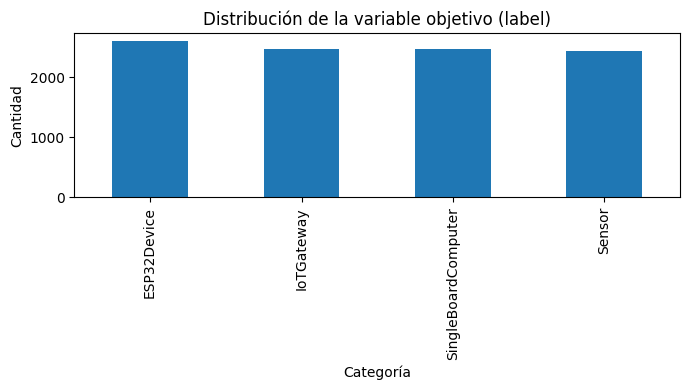

In [14]:
import matplotlib.pyplot as plt

vc = df["label"].value_counts()

plt.figure(figsize=(7,4))
vc.plot(kind="bar")
plt.title("Distribución de la variable objetivo (label)")
plt.xlabel("Categoría")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

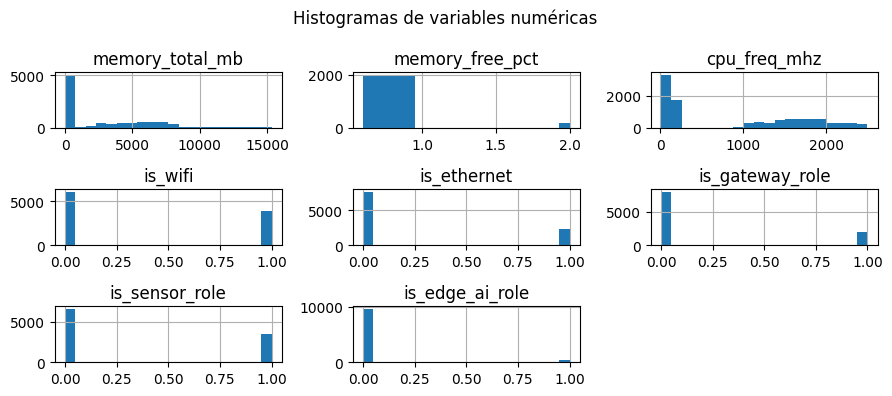

In [15]:
df[numeric_columns].hist(bins=20, figsize=(9,4))
plt.suptitle("Histogramas de variables numéricas")
plt.tight_layout()
plt.show()

In [16]:
corr = df[numeric_columns].corr(method="pearson")
corr

,memory_total_mb,memory_free_pct,cpu_freq_mhz,is_wifi,is_ethernet,is_gateway_role,is_sensor_role,is_edge_ai_role
memory_total_mb,1.000000,-0.005401,0.774294,-0.010253,0.332449,0.295967,-0.584343,0.347926
memory_free_pct,-0.005401,1.000000,0.006180,0.000574,0.004944,-0.011244,-0.001939,-0.005921
cpu_freq_mhz,0.774294,0.006180,1.000000,-0.039993,0.328290,0.340538,-0.700270,0.192312
is_wifi,-0.010253,0.000574,-0.039993,1.000000,-0.447135,-0.003473,-0.011068,0.029941
is_ethernet,0.332449,0.004944,0.328290,-0.447135,1.000000,0.210653,-0.335156,0.143214
is_gateway_role,0.295967,-0.011244,0.340538,-0.003473,0.210653,1.000000,-0.355587,-0.099753
is_sensor_role,-0.584343,-0.001939,-0.700270,-0.011068,-0.335156,-0.355587,1.000000,-0.147368
is_edge_ai_role,0.347926,-0.005921,0.192312,0.029941,0.143214,-0.099753,-0.147368,1.000000


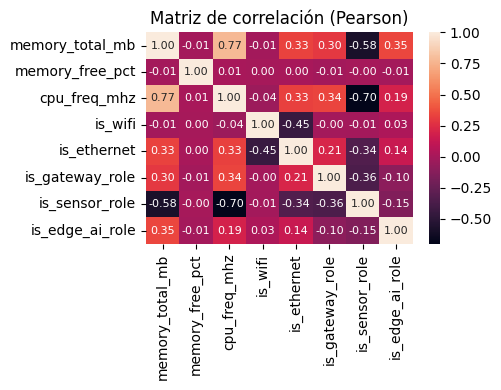

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8}
)
plt.title("Matriz de correlación (Pearson)")
plt.tight_layout()
plt.show()

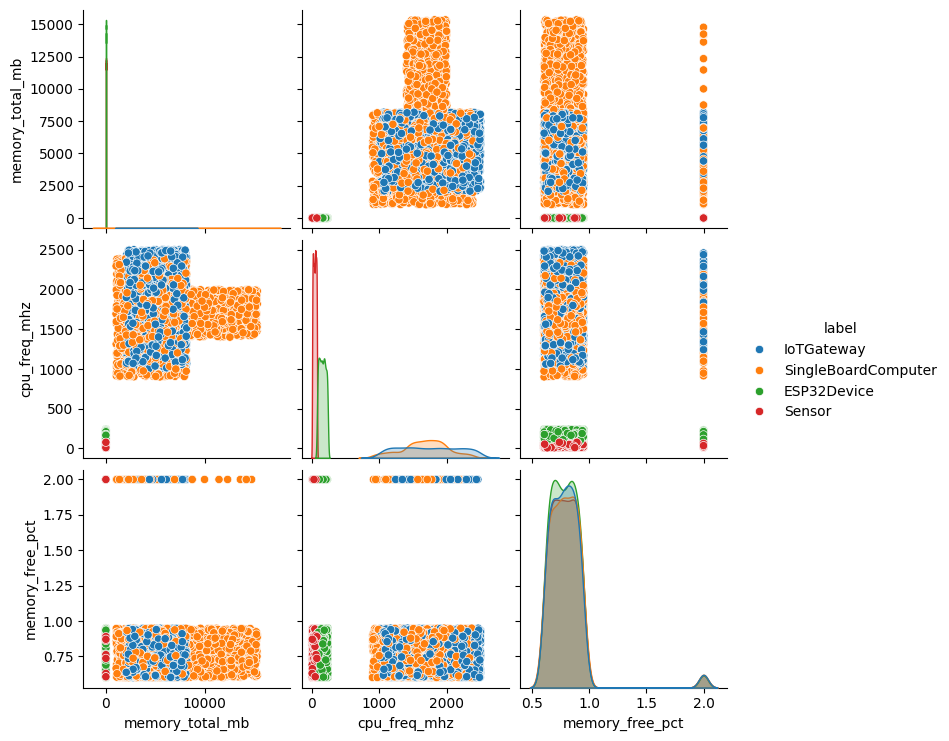

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, hue="label", vars=["memory_total_mb", "cpu_freq_mhz", "memory_free_pct"])
plt.show()

# Preprocesamiento

**Revisamos que no haya valores raros.** Por ejemplo:
* la memoria libre no puede ser mas del 100% ni menos de 0.
* Borrar las filas donde la memoria o el CPU dan 0
* Manejo de NaNs y outliers
* Validacion de distribucion de clases y balances


In [20]:
def clean_transform(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    #Asegurar numéricos
    for c in df.columns:
        if c != "label":
            df[c] = pd.to_numeric(df[c], errors="coerce")

    #NaNs -> imputación simple (0 para flags, mediana para continuas)
    flag_cols = [c for c in df.columns if c.startswith("is_") or c.startswith("has_")]
    cont_cols = [c for c in df.columns if c not in flag_cols + ["label"]]

    df[flag_cols] = df[flag_cols].fillna(0.0)

    for c in cont_cols:
        df[c] = df[c].fillna(df[c].median())

    #Rangos esperados
    if "memory_free_pct" in df.columns:
        df["memory_free_pct"] = df["memory_free_pct"].clip(0.0, 1.0)

    #Filtros de coherencia
    if "memory_total_mb" in df.columns:
        df = df[df["memory_total_mb"] > 0]

    if "cpu_freq_mhz" in df.columns:
        df = df[df["cpu_freq_mhz"] > 0]

    return df.reset_index(drop=True)

df_clean = clean_transform(df)
# df_clean.shape, df.shape

print("Dataset original: ", df.shape)
print("Dataset limpio: ", df_clean.shape)

Dataset original:  (10000, 9)
Dataset limpio:  (10000, 9)


In [21]:
# Eliminar variables de rol (evitar data leakage)
cols_to_remove = [
    "is_gateway_role",
    "is_sensor_role",
    "is_edge_ai_role"
]

df_clean = df_clean.drop(columns=cols_to_remove)

df_clean.head()

,memory_total_mb,memory_free_pct,cpu_freq_mhz,is_wifi,is_ethernet,label
0,2178.181872,0.790730,1191,0,0,IoTGateway
1,5474.691278,0.787680,1494,0,1,SingleBoardComputer
2,7599.381384,0.693442,1503,0,1,SingleBoardComputer
3,4852.179976,0.906729,1114,1,0,IoTGateway
4,0.451058,0.653493,182,0,0,ESP32Device


### LabelEncoder

In [22]:
from sklearn.preprocessing import LabelEncoder
X = df_clean.drop(columns=["label"])
y = df_clean["label"]
le = LabelEncoder()
y_encoded = le.fit_transform(y)

### Split train/test

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.30,
    random_state=SEED,
    stratify=y_encoded
)

### StandardScaler

In [24]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# MLP building and training

In [25]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [26]:
num_classes = len(le.classes_)
model = keras.Sequential([
        layers.Input(shape=(X_train_scaled.shape[1],)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='softmax')
    ])

In [27]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                384       
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 4)                 132       
                                                                 
Total params: 2596 (10.14 KB)
Trainable params: 2596 (10.14 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [ ]:
model.compile(
    optimizer='adam',       
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']                
)

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=10, restore_best_weights=True
    )
]

In [ ]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=80,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)